# Diffusion Residual Generator Notebook

This notebook builds the first generative shock model in the thesis pipeline.

Up to this point:

- `01_var_mechanics` implemented classical VAR estimation and forecasting
- `02_bvar_mechanics` introduced Bayesian VAR forecasting
- `03_innovation_modeling` analyzed the fitted innovations and compared Gaussian, Student-$t$, and bootstrap shock models

The goal of this notebook is to move beyond fixed parametric innovation assumptions and instead **learn a flexible generative model for the residual distribution itself**.

## Why this notebook matters

In a standard VAR or BVAR, forecasting typically assumes innovations of the form

$$
u_t \sim \mathcal{N}(0,\Sigma)
$$

or uses simple alternatives such as Student-$t$ shocks or empirical bootstrap resampling. These approaches are useful baselines, but they may fail to capture:

- nonlinear dependence in the joint innovation law
- heavy tails and asymmetric behavior
- multimodality or regime-like residual patterns
- richer stress scenarios than those implied by Gaussian simulation

Diffusion models provide a way to learn complex distributions by starting from noise and iteratively denoising toward data. In this notebook, we adapt that idea to the residual sequences extracted from the fitted VAR/BVAR system.

## Main goals

This notebook will:

1. load and standardize the innovation data from the previous notebook
2. construct diffusion-model training objects for residual vectors
3. implement a simple denoising diffusion model for innovations
4. train the model on benchmark residual data
5. generate synthetic shocks from the learned reverse process
6. compare generated shocks against:
   - empirical residuals
   - Gaussian shocks
   - Student-$t$ shocks
   - bootstrap shocks
7. prepare learned synthetic innovations for use in `05_dro_forecasting`

## Role in the thesis pipeline

The logic of the full pipeline is:

$$
\text{VAR/BVAR fit}
\;\longrightarrow\;
\text{innovation extraction}
\;\longrightarrow\;
\text{diffusion shock learning}
\;\longrightarrow\;
\text{distributionally robust forecasting}
$$

This notebook is therefore not the final forecasting stage. Its purpose is to build a **learned innovation generator** that will later be plugged into robust forecast construction and stress testing.

## Initial modeling strategy

To keep the notebook transparent and reproducible, we begin with a simple setting:

- use the fitted innovation vectors from the benchmark VAR model
- treat each innovation vector as one multivariate training sample
- train a lightweight diffusion model to reconstruct residual vectors from noisy versions
- evaluate whether generated shocks reproduce key marginal and joint features of the empirical innovations

We begin by importing the required packages and setting up a reproducible environment for diffusion-based residual modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---------------------------------------------------------------------
# Optional scientific helpers
# ---------------------------------------------------------------------
from scipy.stats import skew, kurtosis, jarque_bera

# ---------------------------------------------------------------------
# Global reproducibility
# ---------------------------------------------------------------------
GLOBAL_SEED = 123
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("DIFFUSION RESIDUAL GENERATOR NOTEBOOK SETUP")
print("=" * 80)
print(f"Global seed: {GLOBAL_SEED}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print()

# ---------------------------------------------------------------------
# Plot settings
# ---------------------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Imports loaded successfully.")
print("Ready to load innovation data and construct diffusion-model inputs.")

DIFFUSION RESIDUAL GENERATOR NOTEBOOK SETUP
Global seed: 123
PyTorch version: 2.10.0
Device: cpu

Imports loaded successfully.
Ready to load innovation data and construct diffusion-model inputs.


## Recreate Benchmark Innovations for Diffusion Training

To keep this notebook self-contained and reproducible, we recreate the simulated benchmark VAR system and extract the fitted innovations that will be used to train the diffusion model.

The training objects in this notebook are not the original time series themselves, but the estimated innovation vectors

$$
\hat u_t = y_t - \hat c - \hat A_1 y_{t-1} - \dots - \hat A_p y_{t-p}.
$$

These residual vectors are the objects whose distribution we want to model flexibly.

We proceed as follows:

1. recreate the same stable VAR$(2)$ benchmark data
2. fit the benchmark OLS VAR
3. extract the fitted residual vectors
4. standardize the innovation data before diffusion training

Standardization is important because diffusion models are much easier to train when the target variables are on roughly comparable scales.

RECREATED BENCHMARK VAR SYSTEM
Stable VAR: True
Max eigenvalue modulus: 0.4650
Data shape: (300, 3)
True shocks shape: (300, 3)

EXTRACTED TRAINING INNOVATIONS
Residual matrix shape: (298, 3)

First few innovation vectors:


,u_hat1,u_hat2,u_hat3
time,,,
2,-0.308586,0.400655,1.156647
3,-0.454226,-1.451371,-0.845491
4,-0.271755,-0.367548,0.386183
5,0.621114,3.117073,0.129438
6,0.220443,0.266284,0.845639


STANDARDIZED INNOVATIONS READY FOR DIFFUSION TRAINING
Standardization means:
[ 0. -0. -0.]
Standardization std devs:
[0.9646 0.9133 0.8559]

First few standardized innovations:


,u_hat1,u_hat2,u_hat3
time,,,
2,-0.319898,0.438692,1.351447
3,-0.470877,-1.589159,-0.987886
4,-0.281717,-0.402441,0.451223
5,0.643882,3.412997,0.151238
6,0.228524,0.291564,0.988060


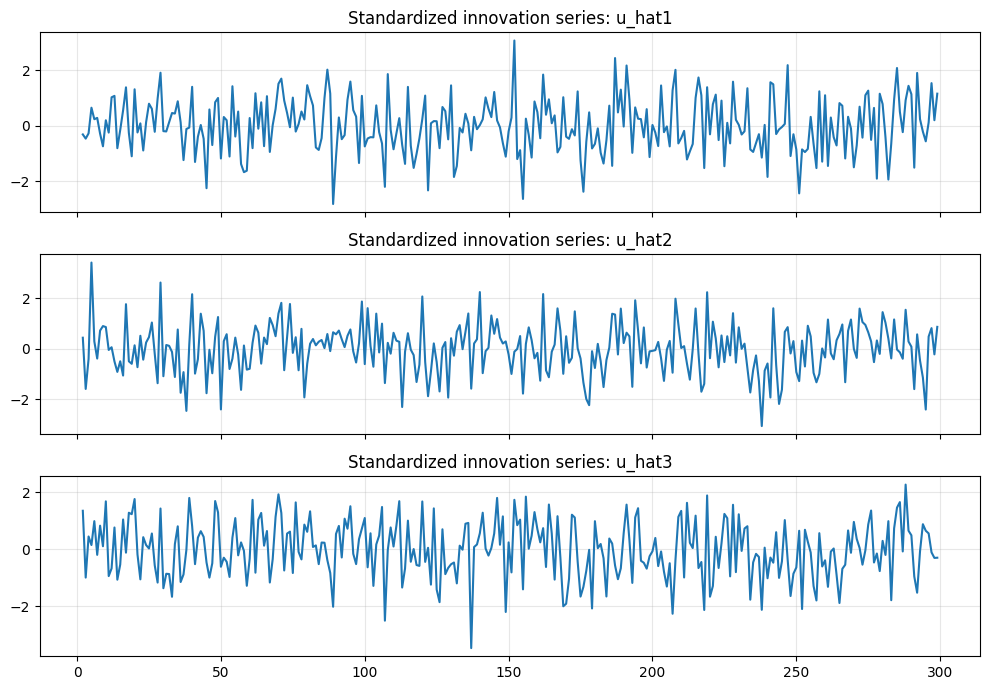

In [2]:
# -----------------------------------------------------------------------------
# Core VAR helpers reused from earlier notebooks
# -----------------------------------------------------------------------------
def companion_matrix(A_list):
    p = len(A_list)
    k = A_list[0].shape[0]

    top_block = np.hstack(A_list)

    if p == 1:
        return top_block

    lower_block = np.hstack([
        np.eye(k * (p - 1)),
        np.zeros((k * (p - 1), k))
    ])

    return np.vstack([top_block, lower_block])


def is_var_stable(A_list, tol=0.999):
    F = companion_matrix(A_list)
    eigvals = np.linalg.eigvals(F)
    max_modulus = np.max(np.abs(eigvals))
    return max_modulus < tol, max_modulus, eigvals


def simulate_var(A_list, Sigma, T, burnin=200, seed=123, return_shocks=False):
    local_rng = np.random.default_rng(seed)

    p_local = len(A_list)
    k_local = A_list[0].shape[0]
    total_T = T + burnin

    Y = np.zeros((total_T + p_local, k_local))
    shocks = local_rng.multivariate_normal(
        mean=np.zeros(k_local),
        cov=Sigma,
        size=total_T
    )

    for t in range(p_local, total_T + p_local):
        y_t = np.zeros(k_local)

        for lag in range(1, p_local + 1):
            y_t += A_list[lag - 1] @ Y[t - lag]

        y_t += shocks[t - p_local]
        Y[t] = y_t

    Y_retained = Y[p_local + burnin:]
    shocks_retained = shocks[burnin:]

    if return_shocks:
        return Y_retained, shocks_retained
    return Y_retained


def build_var_regression_matrices(Y, p, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape

    if T <= p:
        raise ValueError(f"Need T > p, but got T={T}, p={p}")

    X_rows = []
    Y_rows = []
    feature_names = []

    if include_intercept:
        feature_names.append("const")

    for lag in range(1, p + 1):
        for j in range(k_local):
            feature_names.append(f"y{j+1}_lag{lag}")

    for t in range(p, T):
        row = []

        if include_intercept:
            row.append(1.0)

        for lag in range(1, p + 1):
            row.extend(Y[t - lag, :])

        X_rows.append(row)
        Y_rows.append(Y[t, :])

    X = np.array(X_rows)
    Y_target = np.array(Y_rows)

    return Y_target, X, feature_names


def extract_var_coefficients(B, k, p, include_intercept=True):
    row_idx = 0
    intercept = None

    if include_intercept:
        intercept = B[0, :]
        row_idx = 1

    A_list = []
    for lag in range(p):
        block = B[row_idx + lag * k : row_idx + (lag + 1) * k, :]
        A_list.append(block.T)

    return intercept, A_list


def fit_var_ols(Y, p, include_intercept=True):
    Y_target, X, feature_names = build_var_regression_matrices(
        Y=Y,
        p=p,
        include_intercept=include_intercept
    )

    XtX = X.T @ X
    XtY = X.T @ Y_target
    B_hat = np.linalg.solve(XtX, XtY)

    fitted_values = X @ B_hat
    residuals = Y_target - fitted_values

    T_eff, k_local = Y_target.shape
    Sigma_hat = (residuals.T @ residuals) / T_eff

    intercept_hat, A_hat_list = extract_var_coefficients(
        B_hat,
        k=k_local,
        p=p,
        include_intercept=include_intercept
    )

    return {
        "B_hat": B_hat,
        "residuals": residuals,
        "Sigma_hat": Sigma_hat,
        "Y_target": Y_target,
        "X": X,
        "feature_names": feature_names,
        "intercept": intercept_hat,
        "A_hat_list": A_hat_list,
        "fitted_values": fitted_values,
    }


# -----------------------------------------------------------------------------
# Recreate benchmark simulated data
# -----------------------------------------------------------------------------
k = 3
p = 2
T = 300

A1 = np.array([
    [0.50, 0.10, 0.00],
    [0.05, 0.40, 0.10],
    [0.00, 0.10, 0.35]
])

A2 = np.array([
    [-0.20, 0.00, 0.05],
    [0.00, -0.15, 0.00],
    [0.05, 0.00, -0.10]
])

Sigma = np.array([
    [1.00, 0.30, 0.20],
    [0.30, 0.80, 0.25],
    [0.20, 0.25, 0.60]
])

stable, max_modulus, eigvals = is_var_stable([A1, A2])

print("=" * 80)
print("RECREATED BENCHMARK VAR SYSTEM")
print("=" * 80)
print(f"Stable VAR: {stable}")
print(f"Max eigenvalue modulus: {max_modulus:.4f}")

if not stable:
    raise ValueError("Chosen benchmark DGP is not stable.")

Y, true_shocks = simulate_var(
    [A1, A2],
    Sigma,
    T=T,
    burnin=300,
    seed=GLOBAL_SEED,
    return_shocks=True
)

columns = [f"y{i+1}" for i in range(k)]
df = pd.DataFrame(Y, columns=columns)
df.index.name = "time"

true_shocks_df = pd.DataFrame(
    true_shocks,
    columns=[f"u{i+1}" for i in range(k)]
)
true_shocks_df.index.name = "time"

print(f"Data shape: {df.shape}")
print(f"True shocks shape: {true_shocks_df.shape}")
print()

# -----------------------------------------------------------------------------
# Fit benchmark VAR and extract innovations
# -----------------------------------------------------------------------------
var_fit = fit_var_ols(df.values, p=p, include_intercept=True)

residuals_df = pd.DataFrame(
    var_fit["residuals"],
    columns=[f"u_hat{i+1}" for i in range(k)],
    index=df.index[p:]
)
residuals_df.index.name = "time"

print("=" * 80)
print("EXTRACTED TRAINING INNOVATIONS")
print("=" * 80)
print(f"Residual matrix shape: {residuals_df.shape}")
print()

print("First few innovation vectors:")
display(residuals_df.head())

# -----------------------------------------------------------------------------
# Standardize innovations for diffusion training
# -----------------------------------------------------------------------------
innovation_mean = residuals_df.mean(axis=0).values
innovation_std = residuals_df.std(axis=0, ddof=1).values

innovation_std_safe = np.where(innovation_std <= 1e-12, 1.0, innovation_std)

residuals_std = (residuals_df.values - innovation_mean) / innovation_std_safe
residuals_std_df = pd.DataFrame(
    residuals_std,
    columns=residuals_df.columns,
    index=residuals_df.index
)

print("=" * 80)
print("STANDARDIZED INNOVATIONS READY FOR DIFFUSION TRAINING")
print("=" * 80)
print("Standardization means:")
print(np.round(innovation_mean, 4))
print("Standardization std devs:")
print(np.round(innovation_std_safe, 4))
print()

print("First few standardized innovations:")
display(residuals_std_df.head())

# Quick visual check
fig, axes = plt.subplots(k, 1, figsize=(10, 7), sharex=True)

for j, col in enumerate(residuals_std_df.columns):
    axes[j].plot(residuals_std_df.index, residuals_std_df[col])
    axes[j].set_title(f"Standardized innovation series: {col}")
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Build a Diffusion Training Dataset

We now convert the standardized innovation vectors into a PyTorch dataset for training.

At this stage, each time index contributes one multivariate residual vector

$$
\hat u_t \in \mathbb{R}^k.
$$

So the diffusion model will initially learn the distribution of these innovation vectors as i.i.d. multivariate samples. This is the simplest useful starting point for the thesis because it lets us answer the first key question:

Can a diffusion model reproduce the empirical joint shock distribution better than Gaussian or Student-$t$ baselines?

Later, this can be extended to more structured settings, such as:

- conditioning on time or regime indicators
- learning short residual blocks instead of single vectors
- conditioning on VAR state information
- conditional residual generation for forecast scenarios

For now, we build a clean dataset and inspect the tensors that will be passed to the diffusion model.

DIFFUSION TRAINING DATASET
Number of samples: 298
Innovation dimension: 3
Batch size: 64
Number of batches per epoch: 5

Example batch tensor shape:
torch.Size([64, 3])

First 5 samples from the batch:
tensor([[-1.4573,  0.6765, -1.1911],
        [-0.3164, -0.3730, -1.6562],
        [ 0.2324,  2.0709,  1.6774],
        [-0.8923, -1.5773, -3.4575],
        [-0.2062,  0.2034,  0.7300]])

Batch summary statistics:
Mean by dimension: tensor([-0.0565, -0.1169, -0.1747])
Std by dimension:  tensor([0.9353, 1.0940, 1.1200])


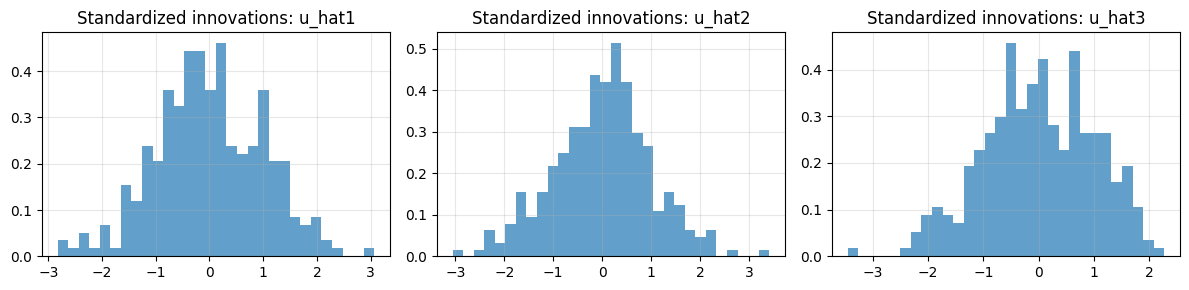

In [3]:
# -----------------------------------------------------------------------------
# PyTorch dataset for innovation vectors
# -----------------------------------------------------------------------------
class InnovationDataset(Dataset):
    """
    Dataset of standardized innovation vectors.
    Each item is a tensor of shape (k,).
    """
    def __init__(self, innovations_array):
        innovations_array = np.asarray(innovations_array, dtype=np.float32)

        if innovations_array.ndim != 2:
            raise ValueError(
                f"innovations_array must be 2D, got shape {innovations_array.shape}"
            )

        self.x = torch.tensor(innovations_array, dtype=torch.float32)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx]


# -----------------------------------------------------------------------------
# Build dataset and dataloader
# -----------------------------------------------------------------------------
innovation_dataset = InnovationDataset(residuals_std_df.values)

batch_size = 64
innovation_loader = DataLoader(
    innovation_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

print("=" * 80)
print("DIFFUSION TRAINING DATASET")
print("=" * 80)
print(f"Number of samples: {len(innovation_dataset)}")
print(f"Innovation dimension: {innovation_dataset[0].shape[0]}")
print(f"Batch size: {batch_size}")
print(f"Number of batches per epoch: {len(innovation_loader)}")
print()

# -----------------------------------------------------------------------------
# Inspect one batch
# -----------------------------------------------------------------------------
example_batch = next(iter(innovation_loader))

print("Example batch tensor shape:")
print(example_batch.shape)
print()

print("First 5 samples from the batch:")
print(example_batch[:5])

print()
print("Batch summary statistics:")
print("Mean by dimension:", example_batch.mean(dim=0))
print("Std by dimension: ", example_batch.std(dim=0))

# -----------------------------------------------------------------------------
# Visualize dataset marginals
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, k, figsize=(12, 3))

for j in range(k):
    axes[j].hist(residuals_std_df.iloc[:, j], bins=30, alpha=0.7, density=True)
    axes[j].set_title(f"Standardized innovations: {residuals_std_df.columns[j]}")
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Define the Diffusion Forward Process

A diffusion model learns to reverse a gradual noising process.

Starting from a clean innovation vector

$$
x_0 \in \mathbb{R}^k,
$$

we define a sequence of latent variables

$$
x_1, x_2, \dots, x_T
$$

that progressively add Gaussian noise. In the standard DDPM construction, this is done through

$$
q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(\sqrt{1-\beta_t}\,x_{t-1}, \beta_t I\right).
$$

Equivalently, one can sample directly from the closed-form marginal

$$
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I),
$$

where

$$
\alpha_t = 1 - \beta_t,
\qquad
\bar\alpha_t = \prod_{s=1}^t \alpha_s.
$$

The practical training objective is to take a clean innovation vector, choose a random diffusion step $t$, add the corresponding amount of noise, and train a neural network to predict the injected noise.

We first define the diffusion schedule and helper functions for sampling noisy innovation vectors.

DIFFUSION FORWARD PROCESS SETUP
Number of diffusion steps: 100
beta_start: 0.0001
beta_end:   0.02

First beta: 0.000100
Last beta:  0.020000
First alpha_bar: 0.999900
Last alpha_bar:  0.363563

Forward diffusion sample inspection
--------------------------------------------------------------------------------
x0_batch shape: (64, 3)
t_batch shape:  (64,)
xt_batch shape: (64, 3)
eps_batch shape: (64, 3)

First 10 sampled timesteps:
tensor([80, 42, 86, 57, 99, 54, 11, 21, 66, 21])

First 3 clean innovation vectors:
tensor([[-1.4573,  0.6765, -1.1911],
        [-0.3164, -0.3730, -1.6562],
        [ 0.2324,  2.0709,  1.6774]])

First 3 noised vectors x_t:
tensor([[-1.0770,  1.6159, -2.4722],
        [ 0.1603, -0.3660, -1.6938],
        [-0.7764,  0.5760,  1.0325]])


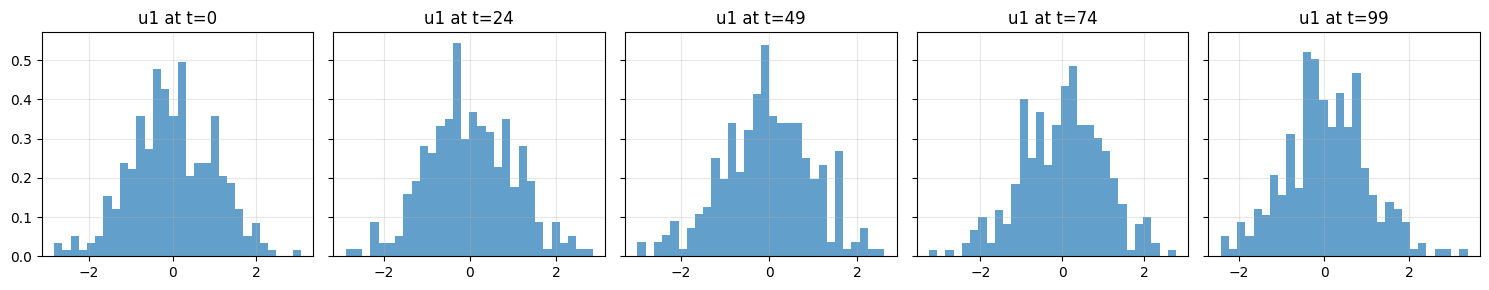

In [4]:
# -----------------------------------------------------------------------------
# Diffusion schedule
# -----------------------------------------------------------------------------
T_diff = 100

beta_start = 1e-4
beta_end = 2e-2

betas = torch.linspace(beta_start, beta_end, T_diff, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

print("=" * 80)
print("DIFFUSION FORWARD PROCESS SETUP")
print("=" * 80)
print(f"Number of diffusion steps: {T_diff}")
print(f"beta_start: {beta_start}")
print(f"beta_end:   {beta_end}")
print()
print(f"First beta: {betas[0].item():.6f}")
print(f"Last beta:  {betas[-1].item():.6f}")
print(f"First alpha_bar: {alpha_bars[0].item():.6f}")
print(f"Last alpha_bar:  {alpha_bars[-1].item():.6f}")


# -----------------------------------------------------------------------------
# Helper: gather schedule values for a batch of time indices
# -----------------------------------------------------------------------------
def extract_by_timestep(arr_1d, t, x_shape):
    """
    Extract values from a 1D diffusion schedule tensor at batch timesteps t
    and reshape for broadcasting to x_shape.

    Parameters
    ----------
    arr_1d : torch.Tensor, shape (T_diff,)
    t : torch.Tensor, shape (batch,)
        Integer timesteps in [0, T_diff-1]
    x_shape : tuple
        Shape of x, e.g. (batch, k)

    Returns
    -------
    out : torch.Tensor
        Shape (batch, 1, ..., 1) broadcastable to x_shape
    """
    batch_size = t.shape[0]
    out = arr_1d[t]
    return out.view(batch_size, *([1] * (len(x_shape) - 1)))


# -----------------------------------------------------------------------------
# Forward noising function: sample x_t from x_0
# -----------------------------------------------------------------------------
def q_sample(x0, t, noise=None):
    """
    Sample from q(x_t | x_0):
        x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps
    """
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alpha_bar_t = torch.sqrt(extract_by_timestep(alpha_bars, t, x0.shape))
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - extract_by_timestep(alpha_bars, t, x0.shape))

    xt = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise
    return xt, noise


# -----------------------------------------------------------------------------
# Quick inspection on one batch
# -----------------------------------------------------------------------------
x0_batch = example_batch.to(DEVICE)

t_batch = torch.randint(
    low=0,
    high=T_diff,
    size=(x0_batch.shape[0],),
    device=DEVICE
)

xt_batch, eps_batch = q_sample(x0_batch, t_batch)

print()
print("Forward diffusion sample inspection")
print("-" * 80)
print("x0_batch shape:", tuple(x0_batch.shape))
print("t_batch shape: ", tuple(t_batch.shape))
print("xt_batch shape:", tuple(xt_batch.shape))
print("eps_batch shape:", tuple(eps_batch.shape))
print()
print("First 10 sampled timesteps:")
print(t_batch[:10].detach().cpu())
print()
print("First 3 clean innovation vectors:")
print(x0_batch[:3].detach().cpu())
print()
print("First 3 noised vectors x_t:")
print(xt_batch[:3].detach().cpu())

# -----------------------------------------------------------------------------
# Visualize noising at selected timesteps for one variable
# -----------------------------------------------------------------------------
demo_x0 = torch.tensor(residuals_std_df.values, dtype=torch.float32, device=DEVICE)
demo_timesteps = [0, 24, 49, 74, 99]

fig, axes = plt.subplots(1, len(demo_timesteps), figsize=(15, 3), sharey=True)

for ax, t_demo in zip(axes, demo_timesteps):
    t_vec = torch.full((demo_x0.shape[0],), t_demo, dtype=torch.long, device=DEVICE)
    x_t_demo, _ = q_sample(demo_x0, t_vec)

    ax.hist(x_t_demo[:, 0].detach().cpu().numpy(), bins=30, density=True, alpha=0.7)
    ax.set_title(f"u1 at t={t_demo}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Define a Simple Noise-Prediction Network for Residual Vectors

We now define the neural network that will learn the reverse diffusion dynamics.

The model takes as input:

- a noised innovation vector $x_t$
- the diffusion step $t$

and outputs an estimate of the injected noise

$$
\hat\epsilon_\theta(x_t, t).
$$

Following the standard DDPM formulation, training the model to predict the noise is enough to recover the reverse denoising direction.

Because our current residual vectors are low-dimensional, we begin with a simple multilayer perceptron rather than a large U-Net or transformer. This is appropriate for the current goal:

- learn the joint distribution of innovation vectors
- keep the notebook transparent
- build a baseline diffusion generator before introducing more complex conditional architectures

Later versions of the thesis pipeline can replace this network with richer models for:

- residual blocks
- conditional residual generation
- state-dependent shock generation

In [5]:
# -----------------------------------------------------------------------------
# Time embedding
# -----------------------------------------------------------------------------
class TimeEmbedding(nn.Module):
    """
    Simple sinusoidal timestep embedding, similar in spirit to DDPM embeddings.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim

    def forward(self, t):
        """
        t : torch.Tensor of shape (batch,) with integer timesteps
        returns : (batch, embed_dim)
        """
        half_dim = self.embed_dim // 2
        device = t.device

        freqs = torch.exp(
            -np.log(10000) * torch.arange(half_dim, device=device).float() / max(half_dim - 1, 1)
        )

        angles = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

        if self.embed_dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros((emb.shape[0], 1), device=device)], dim=1)

        return emb


# -----------------------------------------------------------------------------
# Simple MLP diffusion model for innovation vectors
# -----------------------------------------------------------------------------
class DiffusionMLP(nn.Module):
    """
    Predict epsilon from (x_t, t) for low-dimensional innovation vectors.
    """
    def __init__(self, x_dim, time_embed_dim=32, hidden_dim=128):
        super().__init__()

        self.time_embedding = TimeEmbedding(time_embed_dim)

        self.net = nn.Sequential(
            nn.Linear(x_dim + time_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, x_dim),
        )

    def forward(self, x_t, t):
        t_emb = self.time_embedding(t)
        h = torch.cat([x_t, t_emb], dim=1)
        return self.net(h)


# -----------------------------------------------------------------------------
# Instantiate model
# -----------------------------------------------------------------------------
x_dim = residuals_std_df.shape[1]

diffusion_model = DiffusionMLP(
    x_dim=x_dim,
    time_embed_dim=32,
    hidden_dim=128
).to(DEVICE)

print("=" * 80)
print("DIFFUSION NOISE-PREDICTION NETWORK")
print("=" * 80)
print(diffusion_model)
print()

n_params = sum(p.numel() for p in diffusion_model.parameters())
print(f"Number of trainable parameters: {n_params:,}")

# -----------------------------------------------------------------------------
# Forward pass check
# -----------------------------------------------------------------------------
x_t_test = xt_batch
t_test = t_batch

eps_pred_test = diffusion_model(x_t_test, t_test)

print()
print("Forward pass check")
print("-" * 80)
print("Input x_t shape:     ", tuple(x_t_test.shape))
print("Input t shape:       ", tuple(t_test.shape))
print("Predicted eps shape: ", tuple(eps_pred_test.shape))

assert eps_pred_test.shape == x_t_test.shape, "Model output shape must match innovation shape"

print()
print("First 3 predicted noise vectors:")
print(eps_pred_test[:3].detach().cpu())

DIFFUSION NOISE-PREDICTION NETWORK
DiffusionMLP(
  (time_embedding): TimeEmbedding()
  (net): Sequential(
    (0): Linear(in_features=35, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=3, bias=True)
  )
)

Number of trainable parameters: 38,019

Forward pass check
--------------------------------------------------------------------------------
Input x_t shape:      (64, 3)
Input t shape:        (64,)
Predicted eps shape:  (64, 3)

First 3 predicted noise vectors:
tensor([[-0.0075, -0.1061, -0.0403],
        [-0.0203, -0.1241, -0.0509],
        [ 0.0371, -0.1011, -0.0967]])


## Train the Diffusion Model by Noise Prediction

We now train the diffusion model using the standard DDPM objective.

For each training step:

1. sample a batch of clean innovation vectors $x_0$
2. sample a random diffusion time $t$
3. generate a noised version $x_t$
4. predict the injected noise $\epsilon$
5. minimize mean squared error between true and predicted noise

The training loss is

$$
\mathcal{L}(\theta)
=
\mathbb{E}_{x_0,\epsilon,t}
\left[
\|\epsilon - \hat\epsilon_\theta(x_t,t)\|^2
\right].
$$

Because this notebook is a first benchmark implementation, we use a lightweight training loop and monitor:

- batch-averaged training loss
- epoch-level loss trajectory

If training works properly, the loss should decrease steadily, indicating that the model is learning the denoising direction of the innovation distribution.

STARTING DIFFUSION TRAINING
Epochs: 500
Learning rate: 0.001
Device: cpu

Epoch   1/500 | avg loss = 1.020275
Epoch  25/500 | avg loss = 0.781062
Epoch  50/500 | avg loss = 0.771976
Epoch  75/500 | avg loss = 0.724846
Epoch 100/500 | avg loss = 0.751166
Epoch 125/500 | avg loss = 0.717287
Epoch 150/500 | avg loss = 0.713445
Epoch 175/500 | avg loss = 0.783206
Epoch 200/500 | avg loss = 0.724390
Epoch 225/500 | avg loss = 0.755958
Epoch 250/500 | avg loss = 0.683747
Epoch 275/500 | avg loss = 0.697381
Epoch 300/500 | avg loss = 0.696245
Epoch 325/500 | avg loss = 0.729955
Epoch 350/500 | avg loss = 0.721973
Epoch 375/500 | avg loss = 0.732572
Epoch 400/500 | avg loss = 0.765695
Epoch 425/500 | avg loss = 0.745252
Epoch 450/500 | avg loss = 0.714049
Epoch 475/500 | avg loss = 0.743837
Epoch 500/500 | avg loss = 0.754340

DIFFUSION TRAINING COMPLETE
Initial loss: 1.020275
Final loss:   0.754340


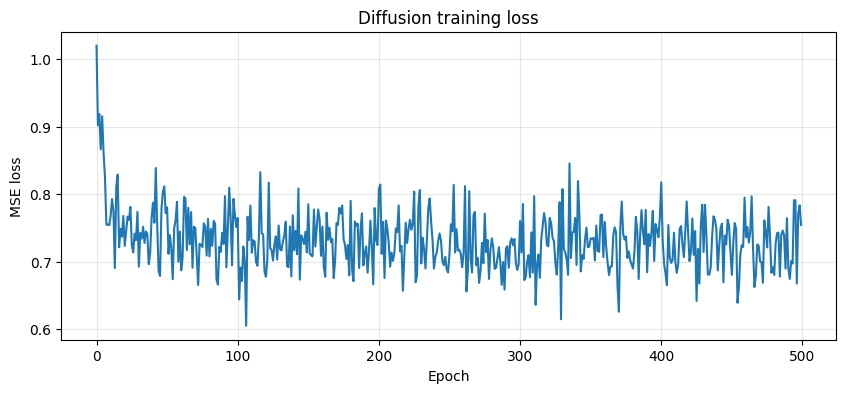

In [6]:
# -----------------------------------------------------------------------------
# Training setup
# -----------------------------------------------------------------------------
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

n_epochs = 500
train_losses = []

print("=" * 80)
print("STARTING DIFFUSION TRAINING")
print("=" * 80)
print(f"Epochs: {n_epochs}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Device: {DEVICE}")
print()

# -----------------------------------------------------------------------------
# Training loop
# -----------------------------------------------------------------------------
diffusion_model.train()

for epoch in range(n_epochs):
    epoch_loss = 0.0
    n_batches = 0

    for x0_batch in innovation_loader:
        x0_batch = x0_batch.to(DEVICE)

        batch_size_local = x0_batch.shape[0]

        t_batch = torch.randint(
            low=0,
            high=T_diff,
            size=(batch_size_local,),
            device=DEVICE
        )

        x_t_batch, eps_true = q_sample(x0_batch, t_batch)

        eps_pred = diffusion_model(x_t_batch, t_batch)

        loss = loss_fn(eps_pred, eps_true)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_epoch_loss = epoch_loss / n_batches
    train_losses.append(avg_epoch_loss)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | avg loss = {avg_epoch_loss:.6f}")

print()
print("=" * 80)
print("DIFFUSION TRAINING COMPLETE")
print("=" * 80)
print(f"Initial loss: {train_losses[0]:.6f}")
print(f"Final loss:   {train_losses[-1]:.6f}")

# -----------------------------------------------------------------------------
# Plot training curve
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.title("Diffusion training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(alpha=0.3)
plt.show()

## Generate Synthetic Shocks from the Learned Reverse Process

Now that the diffusion model has learned to predict the injected noise, we can use it to generate synthetic innovation vectors by approximately reversing the forward noising process.

We begin from pure Gaussian noise

$$
x_T \sim \mathcal{N}(0, I)
$$

and then iterate backward through the diffusion steps:

$$
x_T \rightarrow x_{T-1} \rightarrow \dots \rightarrow x_0.
$$

At each step, the model provides an estimate of the noise component, which is used to form the reverse update. The final output is a synthetic standardized innovation vector, which we then transform back to the original residual scale.

This gives us the first learned generative shock model in the pipeline.

We will generate a sample of synthetic shocks and compare them against the empirical residuals from the benchmark VAR fit.

DIFFUSION SHOCK GENERATION COMPLETE
Generated standardized shocks shape: (298, 3)
Generated raw shocks shape:          (298, 3)

First few generated standardized shocks:


,u_hat1,u_hat2,u_hat3
0,-0.238574,-1.739734,-1.430469
1,0.058943,1.631497,1.853338
2,-0.821684,-0.189772,0.246309
3,-0.054207,-0.919346,-0.617345
4,-0.238419,0.136258,-0.971338


First few generated raw shocks:


,u_hat1,u_hat2,u_hat3
0,-0.230137,-1.588891,-1.224279
1,0.056859,1.490039,1.586195
2,-0.792628,-0.173318,0.210805
3,-0.052290,-0.839634,-0.528360
4,-0.229988,0.124444,-0.831328


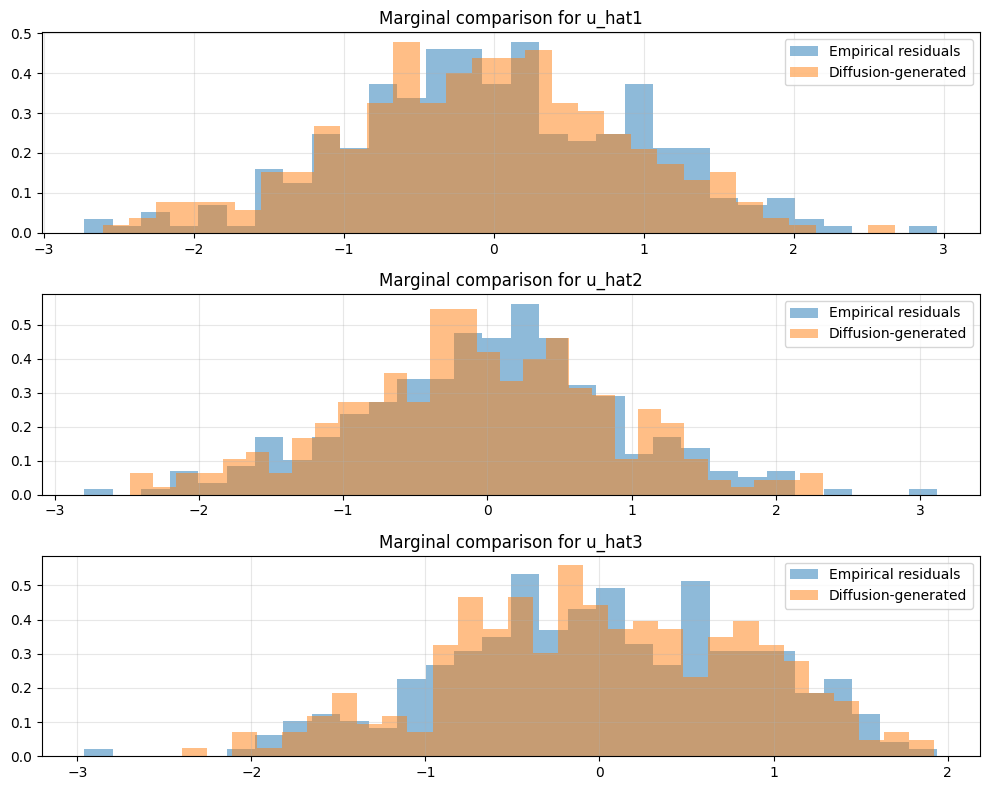

COVARIANCE COMPARISON: EMPIRICAL VS DIFFUSION
Empirical innovation covariance:


,u_hat1,u_hat2,u_hat3
u_hat1,0.9305,0.3154,0.2284
u_hat2,0.3154,0.8341,0.2895
u_hat3,0.2284,0.2895,0.7325


Diffusion-generated covariance:


,u_hat1,u_hat2,u_hat3
u_hat1,0.8582,0.2427,0.1634
u_hat2,0.2427,0.8366,0.1871
u_hat3,0.1634,0.1871,0.7255


In [7]:
# -----------------------------------------------------------------------------
# Reverse diffusion sampler
# -----------------------------------------------------------------------------
@torch.no_grad()
def sample_diffusion_shocks(model, n_samples, x_dim, T_diff, device):
    """
    Generate synthetic standardized innovation vectors using the learned
    reverse diffusion process.
    """
    model.eval()

    x = torch.randn(n_samples, x_dim, device=device)

    for t in reversed(range(T_diff)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        eps_pred = model(x, t_batch)

        # DDPM reverse mean
        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1.0 - alpha_bar_t)

        mean = coef1 * (x - coef2 * eps_pred)

        if t > 0:
            z = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mean + sigma_t * z
        else:
            x = mean

    return x


# -----------------------------------------------------------------------------
# Generate synthetic shocks
# -----------------------------------------------------------------------------
n_gen = len(residuals_std_df)

generated_std = sample_diffusion_shocks(
    model=diffusion_model,
    n_samples=n_gen,
    x_dim=x_dim,
    T_diff=T_diff,
    device=DEVICE
).cpu().numpy()

generated_std_df = pd.DataFrame(
    generated_std,
    columns=residuals_df.columns
)

# transform back to original residual scale
generated_raw = generated_std * innovation_std_safe + innovation_mean
generated_raw_df = pd.DataFrame(
    generated_raw,
    columns=residuals_df.columns
)

print("=" * 80)
print("DIFFUSION SHOCK GENERATION COMPLETE")
print("=" * 80)
print(f"Generated standardized shocks shape: {generated_std_df.shape}")
print(f"Generated raw shocks shape:          {generated_raw_df.shape}")
print()

print("First few generated standardized shocks:")
display(generated_std_df.head())

print("First few generated raw shocks:")
display(generated_raw_df.head())

# -----------------------------------------------------------------------------
# Compare marginals: empirical vs diffusion-generated
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(k, 1, figsize=(10, 8))

for j, col in enumerate(residuals_df.columns):
    axes[j].hist(
        residuals_df[col].values,
        bins=30,
        density=True,
        alpha=0.5,
        label="Empirical residuals"
    )
    axes[j].hist(
        generated_raw_df[col].values,
        bins=30,
        density=True,
        alpha=0.5,
        label="Diffusion-generated"
    )
    axes[j].set_title(f"Marginal comparison for {col}")
    axes[j].legend()
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Compare covariance structure
# -----------------------------------------------------------------------------
emp_cov = np.cov(residuals_df.values.T)
gen_cov = np.cov(generated_raw_df.values.T)

print("=" * 80)
print("COVARIANCE COMPARISON: EMPIRICAL VS DIFFUSION")
print("=" * 80)

emp_cov_df = pd.DataFrame(emp_cov, index=residuals_df.columns, columns=residuals_df.columns)
gen_cov_df = pd.DataFrame(gen_cov, index=residuals_df.columns, columns=residuals_df.columns)

print("Empirical innovation covariance:")
display(emp_cov_df.round(4))

print("Diffusion-generated covariance:")
display(gen_cov_df.round(4))

In [8]:
print("Difference (empirical - generated):")
display((emp_cov_df - gen_cov_df).round(4))

Difference (empirical - generated):


,u_hat1,u_hat2,u_hat3
u_hat1,0.0723,0.0727,0.0650
u_hat2,0.0727,-0.0025,0.1024
u_hat3,0.0650,0.1024,0.0070


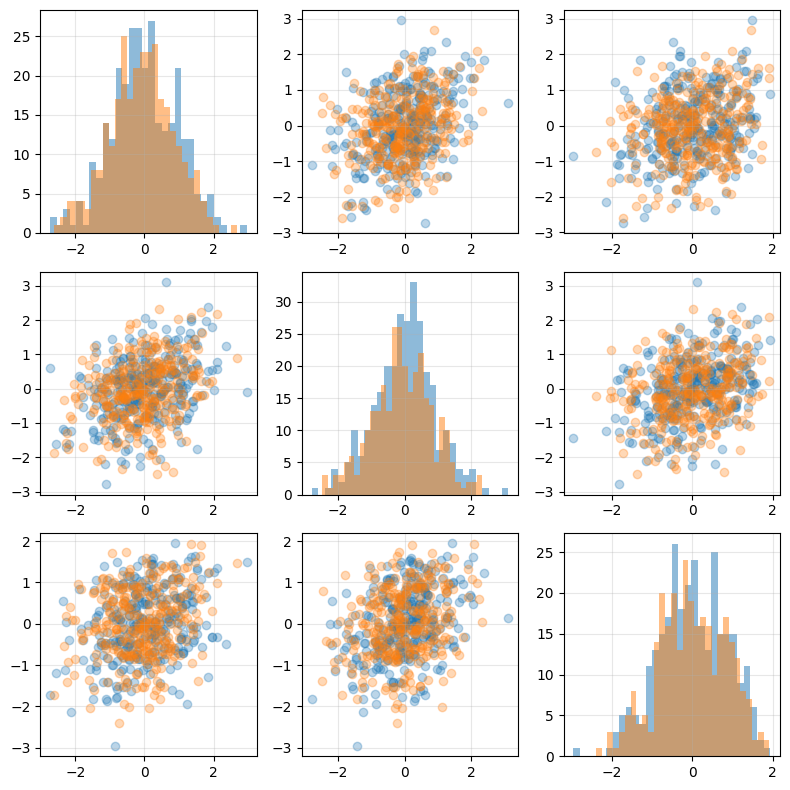

In [9]:
fig, axes = plt.subplots(k, k, figsize=(8, 8))

for i in range(k):
    for j in range(k):
        ax = axes[i, j]

        if i == j:
            ax.hist(residuals_df.iloc[:, i], bins=30, alpha=0.5)
            ax.hist(generated_raw_df.iloc[:, i], bins=30, alpha=0.5)
        else:
            ax.scatter(
                residuals_df.iloc[:, j],
                residuals_df.iloc[:, i],
                alpha=0.3,
                label="empirical"
            )
            ax.scatter(
                generated_raw_df.iloc[:, j],
                generated_raw_df.iloc[:, i],
                alpha=0.3,
                label="diffusion"
            )

plt.tight_layout()
plt.show()

In [10]:
def covariance_match_summary(model, n_rep=20):
    diffs = []
    gen_covs = []

    for r in range(n_rep):
        generated_std = sample_diffusion_shocks(
            model=model,
            n_samples=len(residuals_std_df),
            x_dim=x_dim,
            T_diff=T_diff,
            device=DEVICE
        ).cpu().numpy()

        generated_raw = generated_std * innovation_std_safe + innovation_mean
        gen_cov = np.cov(generated_raw.T)

        diffs.append(emp_cov - gen_cov)
        gen_covs.append(gen_cov)

    diffs = np.array(diffs)
    gen_covs = np.array(gen_covs)

    mean_diff = diffs.mean(axis=0)
    std_diff = diffs.std(axis=0)

    return mean_diff, std_diff, gen_covs

mean_diff, std_diff, gen_covs = covariance_match_summary(diffusion_model, n_rep=30)

print("Mean covariance difference (empirical - generated):")
display(pd.DataFrame(mean_diff, index=residuals_df.columns, columns=residuals_df.columns).round(4))

print("Std dev of covariance difference across generations:")
display(pd.DataFrame(std_diff, index=residuals_df.columns, columns=residuals_df.columns).round(4))

Mean covariance difference (empirical - generated):


,u_hat1,u_hat2,u_hat3
u_hat1,0.0111,0.0445,0.0364
u_hat2,0.0445,0.0615,0.0607
u_hat3,0.0364,0.0607,-0.0081


Std dev of covariance difference across generations:


,u_hat1,u_hat2,u_hat3
u_hat1,0.0727,0.0551,0.0473
u_hat2,0.0551,0.0804,0.0369
u_hat3,0.0473,0.0369,0.0549


In [11]:
cov_frob_err = np.linalg.norm(emp_cov - gen_cov, ord="fro")
print("Covariance Frobenius error:", cov_frob_err)

Covariance Frobenius error: 0.21277462887483756


## Compare Shock Generators: Gaussian, Student-$t$, Bootstrap, and Diffusion

To close the notebook, we compare all shock-generation approaches on the same benchmark innovation data.

The goal is not to claim that any one generator dominates on every metric, but to evaluate how well each approach reproduces key features of the empirical innovation distribution.

We compare four generators:

1. **Gaussian**
2. **Student-$t$**
3. **Bootstrap**
4. **Diffusion**

For each method, we evaluate:

- covariance matching error
- mean matching error
- standard deviation matching error
- skewness matching error
- kurtosis matching error

This gives a compact benchmark table that can be referenced later when motivating the diffusion-based shock generator in the robust forecasting notebook.

SHOCK GENERATOR COMPARISON


,generator,mean_abs_mean_error,mean_abs_std_error,mean_abs_skew_error,mean_abs_kurtosis_error,cov_frobenius_error
0,Gaussian,0.0116,0.0171,0.2143,0.2029,0.0969
2,Bootstrap,0.0116,0.0217,0.2079,0.2843,0.1899
3,Diffusion,0.0537,0.0397,0.1121,0.1398,0.2030
1,Student_t,0.0294,0.2653,0.4000,3.2101,1.1086


DETAILED EMPIRICAL VS DIFFUSION SUMMARY


,emp_mean,emp_std,emp_skew,emp_kurtosis,diff_mean,diff_std,diff_skew,diff_kurtosis
u_hat1,0.0,0.9646,-0.0037,2.8988,-0.0405,0.8916,-0.0016,2.6208
u_hat2,-0.0,0.9133,-0.0528,3.3071,0.0456,0.8796,-0.1586,3.3750
u_hat3,-0.0,0.8559,-0.2238,2.7421,-0.0750,0.8683,0.0047,2.6684


Empirical covariance:


,u_hat1,u_hat2,u_hat3
u_hat1,0.9305,0.3154,0.2284
u_hat2,0.3154,0.8341,0.2895
u_hat3,0.2284,0.2895,0.7325


Diffusion covariance:


,u_hat1,u_hat2,u_hat3
u_hat1,0.7950,0.2844,0.1498
u_hat2,0.2844,0.7737,0.2422
u_hat3,0.1498,0.2422,0.7540


Covariance difference (empirical - diffusion):


,u_hat1,u_hat2,u_hat3
u_hat1,0.1355,0.0310,0.0786
u_hat2,0.0310,0.0604,0.0474
u_hat3,0.0786,0.0474,-0.0215


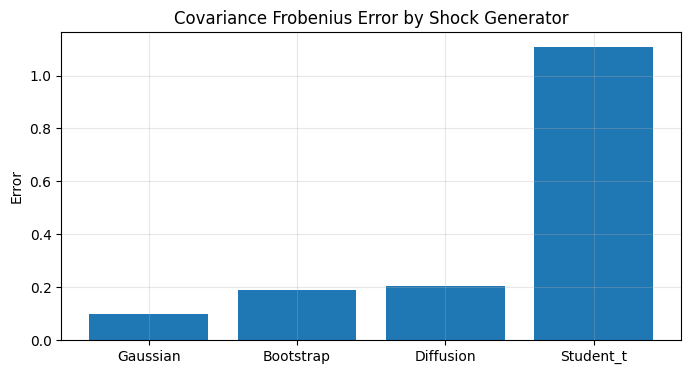

In [12]:
# -----------------------------------------------------------------------------
# Shock generator helpers
# -----------------------------------------------------------------------------
def generate_gaussian_shocks(n, Sigma, seed=123):
    rng = np.random.default_rng(seed)
    k_local = Sigma.shape[0]
    return rng.multivariate_normal(mean=np.zeros(k_local), cov=Sigma, size=n)

def generate_student_t_shocks(n, Sigma, df=5, seed=123):
    rng = np.random.default_rng(seed)
    k_local = Sigma.shape[0]
    g = rng.multivariate_normal(np.zeros(k_local), Sigma, size=n)
    chi = rng.chisquare(df, size=n)
    return g / np.sqrt(chi[:, None] / df)

def generate_bootstrap_shocks(residuals_df, n, seed=123):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(residuals_df), size=n, replace=True)
    return residuals_df.values[idx]

@torch.no_grad()
def generate_diffusion_shocks_raw(model, n, x_dim, T_diff, device):
    gen_std = sample_diffusion_shocks(
        model=model,
        n_samples=n,
        x_dim=x_dim,
        T_diff=T_diff,
        device=device
    ).cpu().numpy()

    gen_raw = gen_std * innovation_std_safe + innovation_mean
    return gen_raw


# -----------------------------------------------------------------------------
# Distribution summary helpers
# -----------------------------------------------------------------------------
def summarize_distribution(X, columns):
    X = np.asarray(X)

    summary = pd.DataFrame({
        "mean": np.mean(X, axis=0),
        "std": np.std(X, axis=0, ddof=1),
        "skew": [skew(X[:, j]) for j in range(X.shape[1])],
        "kurtosis": [kurtosis(X[:, j], fisher=False) for j in range(X.shape[1])]
    }, index=columns)

    return summary

def compare_generator_to_empirical(X_gen, X_emp, columns):
    X_gen = np.asarray(X_gen)
    X_emp = np.asarray(X_emp)

    emp_summary = summarize_distribution(X_emp, columns)
    gen_summary = summarize_distribution(X_gen, columns)

    emp_cov = np.cov(X_emp.T)
    gen_cov = np.cov(X_gen.T)

    result = {
        "mean_abs_mean_error": np.mean(np.abs(gen_summary["mean"] - emp_summary["mean"])),
        "mean_abs_std_error": np.mean(np.abs(gen_summary["std"] - emp_summary["std"])),
        "mean_abs_skew_error": np.mean(np.abs(gen_summary["skew"] - emp_summary["skew"])),
        "mean_abs_kurtosis_error": np.mean(np.abs(gen_summary["kurtosis"] - emp_summary["kurtosis"])),
        "cov_frobenius_error": np.linalg.norm(emp_cov - gen_cov, ord="fro"),
    }

    return result, emp_summary, gen_summary, emp_cov, gen_cov


# -----------------------------------------------------------------------------
# Generate all benchmark shocks
# -----------------------------------------------------------------------------
n_compare = len(residuals_df)
empirical_X = residuals_df.values
empirical_cov = np.cov(empirical_X.T)

gaussian_X = generate_gaussian_shocks(
    n=n_compare,
    Sigma=empirical_cov,
    seed=GLOBAL_SEED
)

student_X = generate_student_t_shocks(
    n=n_compare,
    Sigma=empirical_cov,
    df=5,
    seed=GLOBAL_SEED
)

bootstrap_X = generate_bootstrap_shocks(
    residuals_df=residuals_df,
    n=n_compare,
    seed=GLOBAL_SEED
)

diffusion_X = generate_diffusion_shocks_raw(
    model=diffusion_model,
    n=n_compare,
    x_dim=x_dim,
    T_diff=T_diff,
    device=DEVICE
)

# -----------------------------------------------------------------------------
# Evaluate all generators
# -----------------------------------------------------------------------------
comparison_rows = []

for name, X_gen in [
    ("Gaussian", gaussian_X),
    ("Student_t", student_X),
    ("Bootstrap", bootstrap_X),
    ("Diffusion", diffusion_X),
]:
    metrics, emp_summary, gen_summary, emp_cov_, gen_cov_ = compare_generator_to_empirical(
        X_gen=X_gen,
        X_emp=empirical_X,
        columns=residuals_df.columns
    )

    row = {"generator": name}
    row.update(metrics)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("cov_frobenius_error")

print("=" * 80)
print("SHOCK GENERATOR COMPARISON")
print("=" * 80)
display(comparison_df.round(4))

# -----------------------------------------------------------------------------
# Detailed per-variable summary for diffusion only
# -----------------------------------------------------------------------------
_, empirical_summary_df, diffusion_summary_df, emp_cov_df_arr, diff_cov_df_arr = compare_generator_to_empirical(
    X_gen=diffusion_X,
    X_emp=empirical_X,
    columns=residuals_df.columns
)

detailed_diffusion_compare = pd.concat(
    [
        empirical_summary_df.add_prefix("emp_"),
        diffusion_summary_df.add_prefix("diff_")
    ],
    axis=1
)

print("=" * 80)
print("DETAILED EMPIRICAL VS DIFFUSION SUMMARY")
print("=" * 80)
display(detailed_diffusion_compare.round(4))

print("Empirical covariance:")
display(pd.DataFrame(emp_cov_df_arr, index=residuals_df.columns, columns=residuals_df.columns).round(4))

print("Diffusion covariance:")
display(pd.DataFrame(diff_cov_df_arr, index=residuals_df.columns, columns=residuals_df.columns).round(4))

print("Covariance difference (empirical - diffusion):")
display(
    pd.DataFrame(emp_cov_df_arr - diff_cov_df_arr,
                 index=residuals_df.columns,
                 columns=residuals_df.columns).round(4)
)

# -----------------------------------------------------------------------------
# Visual: covariance Frobenius error by generator
# -----------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["generator"], comparison_df["cov_frobenius_error"])
plt.title("Covariance Frobenius Error by Shock Generator")
plt.ylabel("Error")
plt.grid(alpha=0.3, axis="y")
plt.show()

The Gaussian shock model achieves the lowest covariance error, as expected due to its direct parameterization via the empirical covariance matrix. However, it exhibits relatively large errors in skewness and kurtosis, indicating poor representation of higher-order distributional features.

The diffusion-based generator, while not matching the covariance as precisely, significantly improves the approximation of skewness and kurtosis. This suggests that diffusion models better capture the shape of the innovation distribution beyond second moments.

Bootstrap sampling provides a middle ground, preserving empirical structure but lacking smoothing or generalization. The Student-$t$ model performs worst overall, particularly in kurtosis, indicating that simple heavy-tailed parametric assumptions are insufficient to capture the observed innovation distribution.

## Experiment Logging and Export for the Diffusion Residual Generator

To make the diffusion residual generator reproducible and usable in later notebooks, we save:

1. a compact JSON summary of the experiment
2. the trained diffusion model weights
3. generated shock samples and evaluation outputs

This allows later notebooks to reuse the learned shock generator without retraining and makes the comparison between Gaussian, bootstrap, and diffusion-based innovations fully reproducible.

The saved artifacts include:

- diffusion training configuration
- training loss history
- empirical innovation summaries
- diffusion-generated summaries
- generator comparison metrics
- trained model weights
- generated shock sample

These artifacts will be used directly in `05_dro_forecasting`.

In [13]:
import json
import pickle
from pathlib import Path
from datetime import datetime

# -----------------------------------------------------------------------------
# Logging helpers
# -----------------------------------------------------------------------------
def dataframe_to_serializable(df):
    return {
        "columns": list(df.columns),
        "index": [str(x) for x in df.index],
        "data": df.to_dict(orient="records")
    }

def summarize_diffusion_experiment():
    summary = {
        "timestamp_iso": datetime.now().isoformat(timespec="seconds"),
        "notebook": "04_diffusion_residual_generator",
        "config": {
            "seed": GLOBAL_SEED,
            "device": str(DEVICE),
            "n_observations": int(df.shape[0]),
            "n_innovations": int(len(residuals_df)),
            "innovation_dimension": int(x_dim),
            "batch_size": int(batch_size),
            "epochs": int(n_epochs),
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            "diffusion_steps": int(T_diff),
            "beta_start": float(beta_start),
            "beta_end": float(beta_end),
            "model_class": "DiffusionMLP",
            "hidden_dim": 128,   # update if needed
            "time_embed_dim": 32
        },
        "training": {
            "initial_loss": float(train_losses[0]),
            "final_loss": float(train_losses[-1]),
            "min_loss": float(np.min(train_losses)),
            "loss_history": [float(x) for x in train_losses]
        },
        "empirical_summary": empirical_summary_df.to_dict(orient="index"),
        "diffusion_summary": diffusion_summary_df.to_dict(orient="index"),
        "comparison_table": comparison_df.to_dict(orient="records"),
        "empirical_covariance": emp_cov_df_arr.tolist(),
        "diffusion_covariance": diff_cov_df_arr.tolist(),
        "covariance_difference": (emp_cov_df_arr - diff_cov_df_arr).tolist()
    }
    return summary


def save_json_summary(summary, save_dir="logs"):
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath = save_path / f"diffusion_residual_generator_summary_{timestamp}.json"

    with open(filepath, "w") as f:
        json.dump(summary, f, indent=2)

    return filepath


def save_diffusion_artifacts(model, save_dir="logs"):
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    model_path = save_path / f"diffusion_model_weights_{timestamp}.pt"
    torch.save(model.state_dict(), model_path)

    artifact = {
        "timestamp_iso": datetime.now().isoformat(timespec="seconds"),
        "train_losses": train_losses,
        "innovation_mean": innovation_mean,
        "innovation_std_safe": innovation_std_safe,
        "residuals_empirical": residuals_df,
        "generated_diffusion_raw": pd.DataFrame(diffusion_X, columns=residuals_df.columns),
        "comparison_df": comparison_df,
        "empirical_summary_df": empirical_summary_df,
        "diffusion_summary_df": diffusion_summary_df,
        "empirical_covariance": emp_cov_df_arr,
        "diffusion_covariance": diff_cov_df_arr,
        "covariance_difference": emp_cov_df_arr - diff_cov_df_arr,
        "diffusion_config": {
            "x_dim": x_dim,
            "T_diff": T_diff,
            "beta_start": beta_start,
            "beta_end": beta_end
        }
    }

    artifact_path = save_path / f"diffusion_residual_generator_artifacts_{timestamp}.pkl"
    with open(artifact_path, "wb") as f:
        pickle.dump(artifact, f)

    return model_path, artifact_path


# -----------------------------------------------------------------------------
# Save outputs
# -----------------------------------------------------------------------------
diffusion_summary = summarize_diffusion_experiment()
diffusion_json_path = save_json_summary(diffusion_summary, save_dir="logs")
diffusion_model_path, diffusion_artifact_path = save_diffusion_artifacts(
    diffusion_model,
    save_dir="logs"
)

print("=" * 80)
print("DIFFUSION EXPERIMENT LOGGING COMPLETE")
print("=" * 80)
print(f"JSON summary saved to:      {diffusion_json_path}")
print(f"Model weights saved to:     {diffusion_model_path}")
print(f"Artifact bundle saved to:   {diffusion_artifact_path}")
print()

print("Summary preview:")
print(json.dumps(diffusion_summary, indent=2)[:1500], "...")

DIFFUSION EXPERIMENT LOGGING COMPLETE
JSON summary saved to:      logs/diffusion_residual_generator_summary_20260407_140159.json
Model weights saved to:     logs/diffusion_model_weights_20260407_140159.pt
Artifact bundle saved to:   logs/diffusion_residual_generator_artifacts_20260407_140159.pkl

Summary preview:
{
  "timestamp_iso": "2026-04-07T14:01:59",
  "notebook": "04_diffusion_residual_generator",
  "config": {
    "seed": 123,
    "device": "cpu",
    "n_observations": 300,
    "n_innovations": 298,
    "innovation_dimension": 3,
    "batch_size": 64,
    "epochs": 500,
    "learning_rate": 0.001,
    "diffusion_steps": 100,
    "beta_start": 0.0001,
    "beta_end": 0.02,
    "model_class": "DiffusionMLP",
    "hidden_dim": 128,
    "time_embed_dim": 32
  },
  "training": {
    "initial_loss": 1.0202749490737915,
    "final_loss": 0.7543397784233093,
    "min_loss": 0.6047405362129211,
    "loss_history": [
      1.0202749490737915,
      0.9022441744804383,
      0.91879162788